# Statistics & EDA Lab: Understanding Your Data Before Modeling

## Student Practice Notebook

**Name:** A.Gopichand  
**Register Number:** AP24110010980  
**Date:** 28-08-2026  

## Learning Objectives

After completing this lab, you will be able to:

- Compute and interpret descriptive statistics beyond `.describe()` (variance, std, skewness)
- Visualize and identify distribution shapes (normal vs skewed)
- Compute and interpret correlation between features
- Run a basic hypothesis test (t-test) and interpret a p-value
- Understand confidence intervals conceptually
- Apply statistical thinking to image and text data

### Why this week matters
You now have clean, scaled, encoded data. Before building any model, a good data scientist asks: **what does this data actually look like? Which features seem related? Is a difference I'm seeing real, or just noise?** That's what statistics answers.

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Descriptive Statistics Beyond `.describe()`

`.describe()` gives mean, std, min/max, quartiles. Two more measures matter a lot for understanding data shape:

- **Variance / Std Dev**: how spread out the data is
- **Skewness**: whether the data leans left (negative skew) or right (positive skew), or is symmetric (skew ≈ 0)

### Demonstration


In [2]:
print("Mean:", tips['total_bill'].mean())
print("Median:", tips['total_bill'].median())
print("Variance:", tips['total_bill'].var())
print("Std Dev:", tips['total_bill'].std())
print("Skewness:", tips['total_bill'].skew())


Mean: 19.78594262295082
Median: 17.795
Variance: 79.25293861397826
Std Dev: 8.902411954856856
Skewness: 1.1332130376158205


**Reading skewness:**
- Skew ≈ 0 → roughly symmetric
- Skew > 0 → right-skewed (long tail of high values; mean > median)
- Skew < 0 → left-skewed (long tail of low values; mean < median)


### Student Practice

Compute mean, median, variance, std dev, and skewness for the `tip_pct` column. Based on the mean vs median relationship, is it left-skewed, right-skewed, or roughly symmetric? Write your conclusion.


In [3]:
# Write your answer here
print("Mean:", tips['tip_pct'].mean())
print("Median:", tips['tip_pct'].median())
print("Variance:", tips['tip_pct'].var())
print("Std Dev:", tips['tip_pct'].std())
print("Skewness:", tips['tip_pct'].skew())

Mean: 0.16080258172250472
Median: 0.15476977125802577
Variance: 0.003729814124817058
Std Dev: 0.061072204191571944
Skewness: 3.3492170245653594


**Reflection:** Why can two columns have the *same mean* but very different std dev / skewness? Why does this matter when deciding how to preprocess a feature (recall Week 3 scaling/outliers)?

*Your answer:* Two columns can have the same mean but different spread and shapes. One may have more outliers or be more skewed, so we need to check the standard deviation and skewness before deciding whether to scale or handle outliers.


## Part 2: Visualizing Distributions

Numbers alone can be misleading — always look at the shape too.

### Demonstration


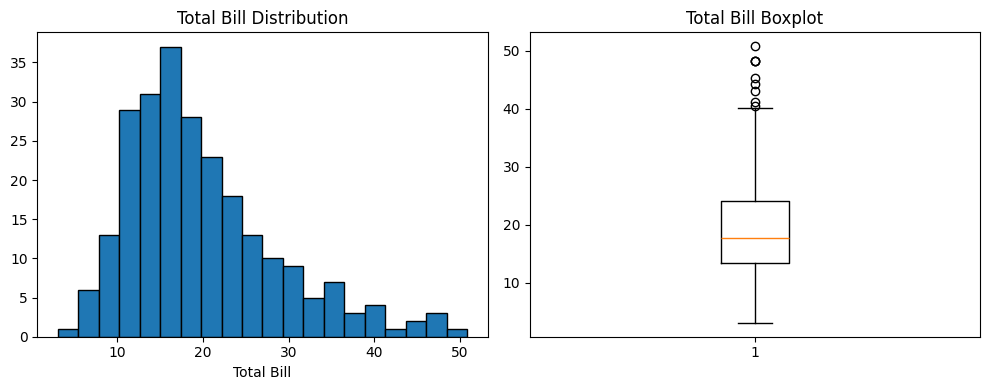

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].hist(tips['total_bill'], bins=20, edgecolor='black')
axes[0].set_title("Total Bill Distribution")
axes[0].set_xlabel("Total Bill")

axes[1].boxplot(tips['total_bill'])
axes[1].set_title("Total Bill Boxplot")

plt.tight_layout()
plt.show()


### Student Practice — predict then check

Predict: will `tip_pct`'s histogram look more symmetric (bell-shaped) or skewed, based on your Part 1 answer? Write your prediction, then plot a histogram and boxplot for `tip_pct` to check.

*Your prediction:* I predict that the tip_pct histogram will be skewed rather than bell-shaped, because in Part 1 its mean was greater than its median, indicating right skew.


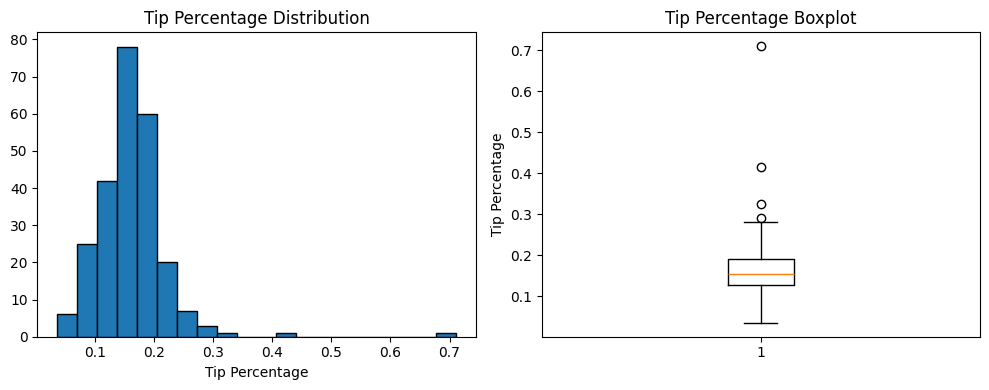

In [5]:
# Write your answer here
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(tips['tip_pct'], bins=20, edgecolor='black')
axes[0].set_title("Tip Percentage Distribution")
axes[0].set_xlabel("Tip Percentage")

axes[1].boxplot(tips['tip_pct'])
axes[1].set_title("Tip Percentage Boxplot")
axes[1].set_ylabel("Tip Percentage")

plt.tight_layout()
plt.show()

## Part 3: Correlation

Correlation measures how strongly two numeric variables move together, from -1 (perfectly inverse) to +1 (perfectly aligned). 0 means no linear relationship.

### Demonstration


Correlation between total_bill and tip: 0.676


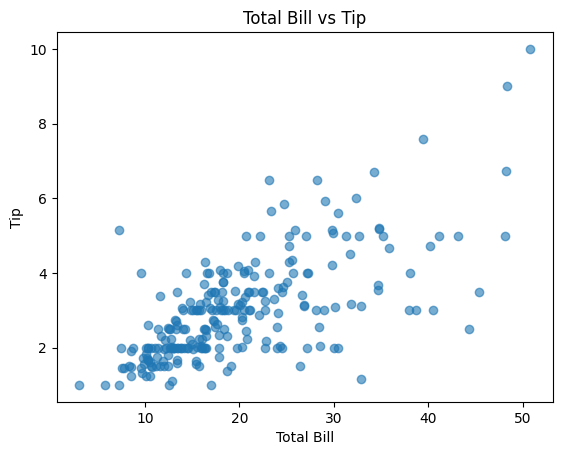

In [6]:
correlation = tips['total_bill'].corr(tips['tip'])
print(f"Correlation between total_bill and tip: {correlation:.3f}")

plt.figure()
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6)
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()


In [7]:
# Correlation matrix across all numeric columns
numeric_cols = tips.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
corr_matrix


,total_bill,tip,size,tip_pct
total_bill,1.000,0.676,0.598,-0.339
tip,0.676,1.000,0.489,0.342
size,0.598,0.489,1.000,-0.143
tip_pct,-0.339,0.342,-0.143,1.000


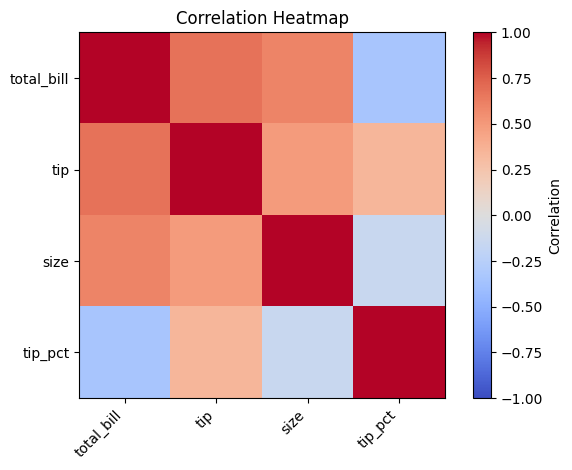

In [8]:
# Visualize as a heatmap
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Student Practice

1. What is the correlation between `size` (party size) and `total_bill`? Is it weak, moderate, or strong?
2. What is the correlation between `size` and `tip_pct`? Compare this to `size` vs `total_bill` — which relationship is stronger, and does that surprise you?


In [9]:
# Write your answer here
print("Correlation between size and total_bill:",
      tips['size'].corr(tips['total_bill']))

print("Correlation between size and tip_pct:",
      tips['size'].corr(tips['tip_pct']))

Correlation between size and total_bill: 0.5983151309049022
Correlation between size and tip_pct: -0.14285960069312365


**Reflection:** Correlation measures a *linear* relationship. Can two variables be strongly related but have a correlation near 0? Explain how that's possible (hint: think about non-linear/curved relationships).

*Your answer:*1. The correlation is approximately 0.60, which is a moderate positive relationship. This means larger parties generally tend to have higher total bills.   
2.The correlation is approximately 0.01, which is a very weak/negligible relationship.


## Part 4: Hypothesis Testing — Is a Difference Real?

You've seen group averages differ (e.g. average tip_pct by day). But is that difference **statistically significant**, or could it just be random variation? A **t-test** compares two group means and gives a **p-value**: the probability of seeing a difference this large (or larger) if there were truly no difference.

**Rule of thumb:** if p-value < 0.05, we consider the difference statistically significant.

### Demonstration: do smokers tip a different percentage than non-smokers?


In [10]:
smoker_tips = tips[tips['smoker']=='Yes']['tip_pct']
nonsmoker_tips = tips[tips['smoker']=='No']['tip_pct']

print("Smoker mean tip_pct:", smoker_tips.mean())
print("Non-smoker mean tip_pct:", nonsmoker_tips.mean())

t_stat, p_value = stats.ttest_ind(smoker_tips, nonsmoker_tips)
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Result: statistically significant difference")
else:
    print("Result: NOT a statistically significant difference (could be random variation)")


Smoker mean tip_pct: 0.16319604463687792
Non-smoker mean tip_pct: 0.15932846217921523

t-statistic: 0.480
p-value: 0.632
Result: NOT a statistically significant difference (could be random variation)


### Student Practice — predict then check

Predict: do you think there's a statistically significant difference in `tip_pct` between Lunch and Dinner? Write your prediction and reasoning, then run a t-test to check.

*Your prediction:* I predict that there may not be a statistically significant difference in tip_pct between Lunch and Dinner. The average tip percentage might be different, but the difference may be small enough to be due to random variation.


In [11]:
# Write your answer here
lunch_tips = tips[tips['time'] == 'Lunch']['tip_pct']
dinner_tips = tips[tips['time'] == 'Dinner']['tip_pct']

print("Lunch mean tip_pct:", lunch_tips.mean())
print("Dinner mean tip_pct:", dinner_tips.mean())

t_stat, p_value = stats.ttest_ind(lunch_tips, dinner_tips)

print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Result: statistically significant difference")
else:
    print("Result: NOT a statistically significant difference (could be random variation)")

Lunch mean tip_pct: 0.164127928162505
Dinner mean tip_pct: 0.15951778877977735

t-statistic: 0.528
p-value: 0.598
Result: NOT a statistically significant difference (could be random variation)


**Reflection:** Why is it important to check statistical significance instead of just comparing two mean values directly and assuming any difference is meaningful?

*Your answer:* It is important to check statistical significance because a difference between two means could happen just by chance. A statistical test helps us decide whether the difference is likely to be a real difference or just random variation.


## Part 5: Confidence Intervals (Conceptual Introduction)

A **confidence interval (CI)** gives a range where we're reasonably confident the true population mean lies, based on our sample. A 95% CI means: if we repeated this sampling process many times, about 95% of such intervals would contain the true mean.

### Demonstration


In [12]:
mean_bill = tips['total_bill'].mean()
sem = stats.sem(tips['total_bill'])  # standard error of the mean
ci = stats.t.interval(0.95, len(tips)-1, loc=mean_bill, scale=sem)

print(f"Sample mean total_bill: {mean_bill:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")


Sample mean total_bill: 19.79
95% Confidence Interval: (18.66, 20.91)


### Student Practice

Compute the 95% confidence interval for `tip_pct`. In one sentence, explain what this interval tells you (in plain language, not just formula terms).


In [13]:
# Write your answer here
mean_tip = tips['tip_pct'].mean()
sem = stats.sem(tips['tip_pct'])
ci = stats.t.interval(0.95, len(tips['tip_pct']) - 1,loc=mean_tip, scale=sem)
print(f"Sample mean tip percentage: {mean_tip:.2f}%")
print(f"95% Confidence Interval: ({ci[0]:.2f}%, {ci[1]:.2f}%)")

Sample mean tip percentage: 0.16%
95% Confidence Interval: (0.15%, 0.17%)


# Mini Project A: Statistical Comparison of Images (Image Track)

Using the image metadata DataFrame you built in Week 2 (filename, brightness, RGB averages, etc.), apply statistical thinking to compare your images.

## Step 1: Rebuild your image metadata table


In [16]:
from google.colab import files
uploaded = files.upload()


Saving cat.jpg to cat.jpg
Saving dog.jpg to dog (1).jpg
Saving parrot.jpg to parrot.jpg


In [17]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
rows = []
for name in filenames:
    arr = np.array(Image.open(name))
    rows.append({
        'filename': name,
        'avg_brightness': np.mean(arr),
        'avg_red': np.mean(arr[:,:,0]) if arr.ndim==3 else np.mean(arr),
        'avg_green': np.mean(arr[:,:,1]) if arr.ndim==3 else np.mean(arr),
        'avg_blue': np.mean(arr[:,:,2]) if arr.ndim==3 else np.mean(arr),
        'height': arr.shape[0],
        'width': arr.shape[1],
    })

image_df = pd.DataFrame(rows)
image_df


,filename,avg_brightness,avg_red,avg_green,avg_blue,height,width
0,cat.jpg,156.211,162.193,155.320,151.118,260,194
1,dog (1).jpg,142.873,161.972,164.174,102.472,553,553
2,parrot.jpg,114.007,125.283,126.768,89.970,300,399


## Step 2: Statistical analysis

1. Compute the mean, std dev, and skewness of `avg_brightness` across your images.
2. Compute the correlation between `avg_brightness` and `avg_red` (do brighter images tend to have more red?).
3. **If you have at least 2 images you can meaningfully group** (e.g. indoor vs outdoor, or any 2 categories you choose), run a t-test comparing their `avg_brightness`. If you only have very few images, skip the t-test and instead just discuss whether a t-test would even be reliable with so few samples.


In [20]:
# Write your answer here
import numpy as np
from scipy import stats

mean_brightness = image_df['avg_brightness'].mean()
std_brightness = image_df['avg_brightness'].std()
skewness = image_df['avg_brightness'].skew()

print("Mean brightness:", mean_brightness)
print("Standard deviation:", std_brightness)
print("Skewness:", skewness)

correlation = image_df['avg_brightness'].corr(image_df['avg_red'])
print("Correlation between brightness and red:", correlation)

print("T-test skipped because there are only 3 images and no meaningful groups.")

Mean brightness: 137.6968730868429
Standard deviation: 21.57262721585775
Skewness: -1.0175345472892043
Correlation between brightness and red: 0.9526120611998227
T-test skipped because there are only 3 images and no meaningful groups.


**Reflection:** With only 3-5 images, can you trust statistical significance results (like a t-test p-value) the same way you would with 200+ rows like the tips dataset? Why or why not?

*Your answer:* With only 3–5 images, statistical results like a t-test p-value may not be reliable because the sample size is too small. With 200+ rows, the results are generally more stable and reliable because there is much more data to support the conclusion.


# Mini Project B: Word Frequency Distribution Analysis (NLP Track)

## Step 1: Build a word frequency table for a longer text

### Demonstration: Zipf's Law preview

A famous finding in linguistics: in most natural language text, word frequency is **highly right-skewed** — a few words (like "the", "a") appear extremely often, and most words appear only once or twice. This is called **Zipf's Law**.


In [18]:
paragraph = (
    "Data science combines statistics and programming. Statistics helps us understand data. "
    "Programming helps us process data. Machine learning is a part of data science. "
    "Data science uses statistics, programming, and machine learning together. "
    "Understanding statistics is essential for data science."
)

tokens = paragraph.lower().replace('.', '').replace(',', '').split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
counts = [np.sum(tokens_array == w) for w in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts}).sort_values('count', ascending=False).reset_index(drop=True)
print(word_freq)
print("\nSkewness of word counts:", word_freq['count'].skew())


             word  count
0            data      6
1         science      4
2      statistics      4
3     programming      3
4             and      2
5              us      2
6              is      2
7        learning      2
8           helps      2
9         machine      2
10      essential      1
11              a      1
12       combines      1
13        process      1
14           part      1
15             of      1
16            for      1
17       together      1
18     understand      1
19  understanding      1
20           uses      1

Skewness of word counts: 1.8510785401434868


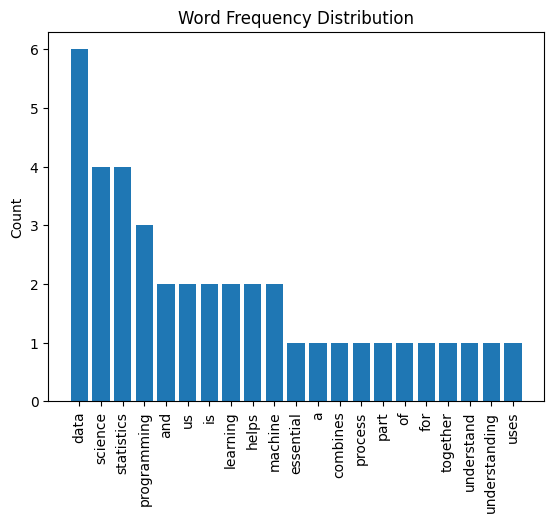

In [19]:
plt.figure()
plt.bar(word_freq['word'], word_freq['count'])
plt.xticks(rotation=90)
plt.title("Word Frequency Distribution")
plt.ylabel("Count")
plt.show()


### Student Practice

1. Pick your own longer paragraph (5+ sentences) and build the same word frequency table.
2. Compute the skewness of the word counts. Is it right-skewed (consistent with Zipf's Law)?
3. What percentage of words in your vocabulary appear only once? (This is usually a large percentage — that's Zipf's Law in action.)


Word Frequency Table:
            word  count
0             ai      7
1     generative      6
2            and      4
3        content      3
4             of      3
5            can      3
6           from      2
7    responsible      2
8     technology      2
9             to      2
10            is      2
11         learn      2
12          data      2
13           use      2
14        people      2
15        create      2
16       amounts      1
17         audio      1
18      becoming      1
19          code      1
20      business      1
21             a      1
22      generate      1
23        future      1
24         forms      1
25        faster      1
26   development      1
27     education      1
28       depends      1
29      complete      1
30            by      1
31            in      1
32          many      1
33       improve      1
34        images      1
35     important      1
36       helping      1
37    healthcare      1
38         other      1
39            on  

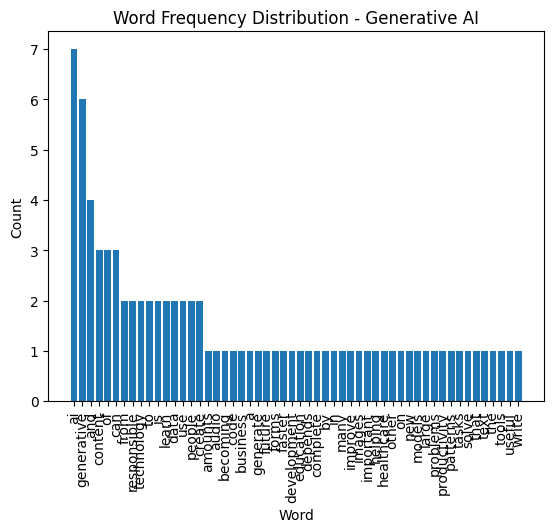

In [21]:
# Write your answer here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

paragraph = (
    "Generative AI is a technology that can create new content from data. "
    "Generative AI can create text, images, audio, and other forms of content. "
    "AI models learn patterns from large amounts of data to generate useful content. "
    "Generative AI is becoming important in education, business, healthcare, and technology. "
    "Many people use generative AI tools to write, learn, code, and solve problems. "
    "Generative AI can improve productivity by helping people complete tasks faster. "
    "The future of generative AI depends on responsible development and responsible use."
)

tokens = paragraph.lower().replace('.', '').replace(',', '').split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
counts = [np.sum(tokens_array == w) for w in vocabulary]
word_freq = pd.DataFrame({
    'word': vocabulary,
    'count': counts
}).sort_values('count', ascending=False).reset_index(drop=True)
print("Word Frequency Table:")
print(word_freq)
skewness = word_freq['count'].skew()
print("\nSkewness of word counts:", skewness)
if skewness > 0:
    print("The word frequency distribution is right-skewed.")
else:
    print("The word frequency distribution is not right-skewed.")
once = np.sum(word_freq['count'] == 1)
total_words = len(word_freq)
percentage = (once / total_words) * 100
print("\nNumber of words appearing only once:", once)
print("Total unique words:", total_words)
print("Percentage of words appearing only once:", percentage, "%")

plt.figure()
plt.bar(word_freq['word'], word_freq['count'])
plt.xticks(rotation=90)
plt.title("Word Frequency Distribution - Generative AI")
plt.xlabel("Word")
plt.ylabel("Count")
plt.show()

## Step 2: Correlation between sentence length and vocabulary diversity

### Demonstration


In [22]:
sentences = [
    "I like data science.",
    "Machine learning models require lots of clean labeled training data to perform well.",
    "Statistics matters.",
    "Understanding both statistics and programming together is essential for real data science work in industry.",
    "NumPy and pandas are useful tools for data analysis in Python."
]

sentence_stats = []
for s in sentences:
    toks = s.lower().replace('.', '').split()
    sentence_stats.append({
        'sentence': s,
        'length': len(toks),
        'unique_words': len(set(toks))
    })

sentence_df = pd.DataFrame(sentence_stats)
sentence_df['diversity_ratio'] = sentence_df['unique_words'] / sentence_df['length']
sentence_df


,sentence,length,unique_words,diversity_ratio
0,I like data science.,4,4,1.0
1,Machine learning models require lots of clean ...,13,13,1.0
2,Statistics matters.,2,2,1.0
3,Understanding both statistics and programming ...,15,15,1.0
4,NumPy and pandas are useful tools for data ana...,11,11,1.0


In [23]:
correlation = sentence_df['length'].corr(sentence_df['unique_words'])
print(f"Correlation between sentence length and unique word count: {correlation:.3f}")


Correlation between sentence length and unique word count: 1.000


### Student Practice

Write 5 sentences of your own, varying in length. Build the same table and compute the correlation between `length` and `unique_words`. Is the correlation strong? Does this match your intuition (longer sentences tend to have more unique words)?


In [24]:
# Write your answer here
import pandas as pd

sentences = [
    "AI is useful.",
    "Generative AI can create new content.",
    "Machine learning models learn patterns from large datasets.",
    "Generative AI helps students understand difficult concepts and solve problems more efficiently.",
    "Modern AI systems use powerful models to generate text, images, code, and other forms of digital content."
]

sentence_stats = []
for s in sentences:
    toks = s.lower().replace('.', '').split()
    sentence_stats.append({
        'sentence': s,
        'length': len(toks),
        'unique_words': len(set(toks))
    })
sentence_df = pd.DataFrame(sentence_stats)
sentence_df['diversity_ratio'] = (
    sentence_df['unique_words'] / sentence_df['length']
)
print(sentence_df)
correlation = sentence_df['length'].corr(
    sentence_df['unique_words']
)
print(f"\nCorrelation between sentence length and unique word count: {correlation:.3f}")

                                            sentence  length  unique_words  \
0                                      AI is useful.       3             3   
1              Generative AI can create new content.       6             6   
2  Machine learning models learn patterns from la...       8             8   
3  Generative AI helps students understand diffic...      12            12   
4  Modern AI systems use powerful models to gener...      17            17   

   diversity_ratio  
0              1.0  
1              1.0  
2              1.0  
3              1.0  
4              1.0  

Correlation between sentence length and unique word count: 1.000


**Reflection:** Why might `diversity_ratio` (unique words / total words) be a more useful metric than raw `unique_words` count when comparing sentences of very different lengths?

*Your answer:*  diversity_ratio is better because it considers sentence length, making comparisons between short and long sentences fairer.


# Final Self-Check

- [Yes] I computed and correctly interpreted skewness (not just mean/std)
- [Yes] I visualized a distribution and connected the shape to the skewness number
- [Yes] I computed correlation and correctly judged strength (weak/moderate/strong)
- [Yes] I ran a t-test and correctly interpreted the p-value (significant or not)
- [Yes] I computed a confidence interval and can explain what it means in plain language
- [Yes] I completed Mini Project A (image stats) or B (text distribution/correlation)
- [Yes] I answered all reflection questions in my own words

## Final Reflection Questions

1. Why is it important to look at data visually (histograms, boxplots) and not just rely on summary numbers like mean and std?

2. If a t-test gives you p = 0.20, what should you conclude, and what should you NOT conclude? (Common misconception to address: "not significant" does not mean "definitely no difference.")

3. How does understanding your data's statistics (distribution shape, correlations) help you make better decisions in the next stage — building an ML model?

4. What's one statistics concept from this lab you still feel unsure about? Be specific.


Answer:
1. Visuals help us see patterns, outliers, and unusual distributions that mean and standard deviation may hide.
2. p = 0.20 means there is not enough evidence to reject the null hypothesis. It does not mean there is definitely no difference.
3. Statistics help us understand patterns, relationships, and unusual values, which helps us choose better features and models.
4. I am still unsure about confidence intervals, especially how to interpret a 95% confidence interval in simple terms.